Exercise 4 (NumPy Array Operations)

In [ ]:
import numpy as np

# Task 1: 5x5 matrix with border 1s and interior 0s
matrix_5x5 = np.ones((5, 5))
matrix_5x5[1:-1, 1:-1] = 0
print("Task 1 Matrix:\n", matrix_5x5)

# Task 2: Normalize a random array
np.random.seed(42)
random_data = np.random.randn(100, 3)
normalized_data = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)
print("\nTask 2-Normalized Mean (should be = 0):", normalized_data.mean(axis=0))
print("Task 2 - Normalized Std (should be = 1):", normalized_data.std(axis=0))

# Task 3: Linear Regression Normal Equation
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

# theta_hat = (X^T * X)^(-1) * X^T * y
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
print("\nTask 3 - True Theta:     ", true_theta)
print("Task 3 - Estimated Theta:", theta_hat)


Task 1 Matrix:
 [[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]

Task 2 - Normalized Mean (should be ~0): [-2.60902411e-17  1.55431223e-17 -8.88178420e-18]
Task 2 - Normalized Std (should be ~1): [1. 1. 1.]

Task 3 - True Theta:      [ 2.5 -1.2  3.7]
Task 3 - Estimated Theta: [ 2.51723721 -1.19783796  3.72399266]


Exercise 5 (Pandas Data Analysis)

In [ ]:
import pandas as pd
import numpy as np

# Setup data wrapper
np.random.seed(42)
n_students = 200
data = {
    "student_id": range(1000, 1000 + n_students),
    "major": np.random.choice(["CS", "Math", "Physics", "Biology"], n_students),
    "year": np.random.choice([1, 2, 3, 4], n_students),
    "exam_score": np.random.normal(75, 10, n_students).clip(0, 100),
    "assignments_completed": np.random.randint(0, 11, n_students),
    "hours_studied": np.random.normal(15, 5, n_students).clip(1, 40),
}
df = pd.DataFrame(data)
df.loc[np.random.choice(n_students, 10), "exam_score"] = np.nan
df.loc[np.random.choice(n_students, 5), "hours_studied"] = np.nan

# Task 1: Data Cleaning
print("--Missing Values Count --")
print(df.isnull().sum())

# Fill missing values with group means/medians
df["exam_score"] = df.groupby("major")["exam_score"].transform(
    lambda x: x.fillna(x.mean())
)
df["hours_studied"] = df.groupby("year")["hours_studied"].transform(
    lambda x: x.fillna(x.median())
)

# Task 2: Analysis of Exam Scores
print("\n--Exam Score Statistics --")
print("\n--Average Exam Score by Major --")
avg_by_major = df.groupby("major")["exam_score"].mean()
print(avg_by_major)
print(f"\nHighest Average Major: {avg_by_major.idxmax()}")

correlation = df["hours_studied"].corr(df["exam_score"])
print(f"Correlation between study hours and exam scores: {correlation:.4f}")


# Custom performance column
def get_performance(score):
    if score > 90:
        return "Excellent"
    elif score > 80:
        return "Good"
    elif score > 70:
        return "Average"
    else:
        return "Needs Improvement"


df["performance"] = df["exam_score"].apply(get_performance)

# Task 3: Advanced Analysis
pivot_summary = (
    df.groupby(["major", "year"])
    .agg(
        student_count=("student_id", "count"),
        avg_exam=("exam_score", "mean"),
        avg_hours=("hours_studied", "mean"),
    )
    .reset_index()
)

top_5 = df.nlargest(5, "exam_score", keep="all")
pivot_table = df.pivot_table(
    values="exam_score", index="major", columns="year", aggfunc="mean"
)

print("\n-- Top 5 Students --")
print(top_5[["student_id", "major", "exam_score"]])



--- Missing Values Count ---
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64

--- Average Exam Score by Major ---
major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64

Highest Average Major: CS
Correlation between study hours and exam scores: -0.0560

--- Top 5 Students ---
     student_id    major  exam_score
27         1027     Math  100.000000
57         1057       CS  100.000000
68         1068  Biology   98.146586
82         1082       CS   96.439441
132        1132       CS   96.330334


Exercise 6 (Data Visualization)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_33308\209805951.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="major", y="exam_score", ax=axes[1], palette="Set2")


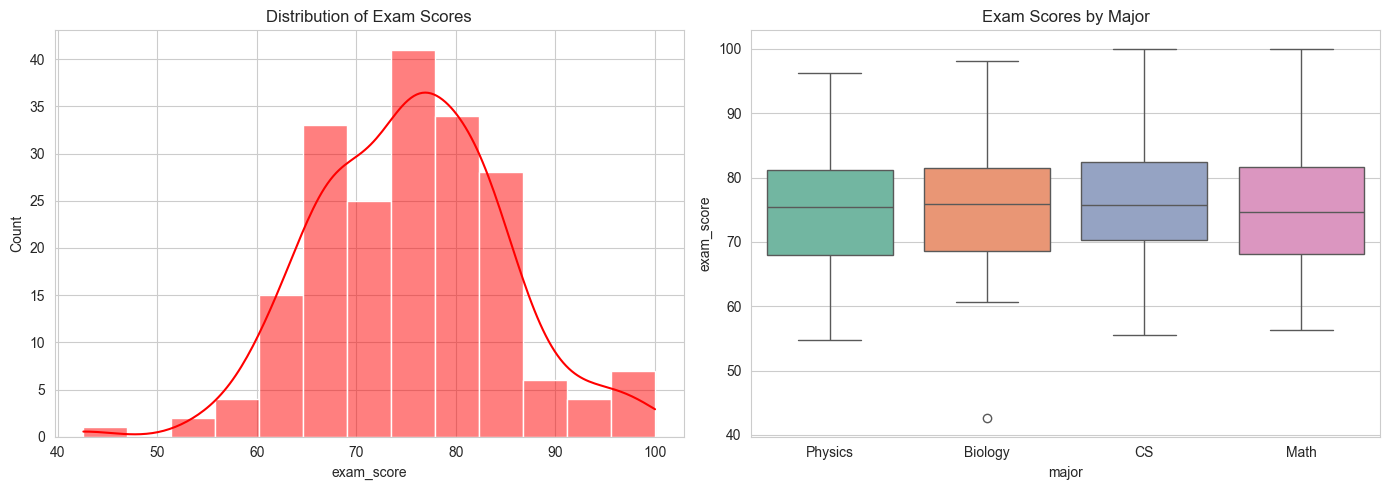

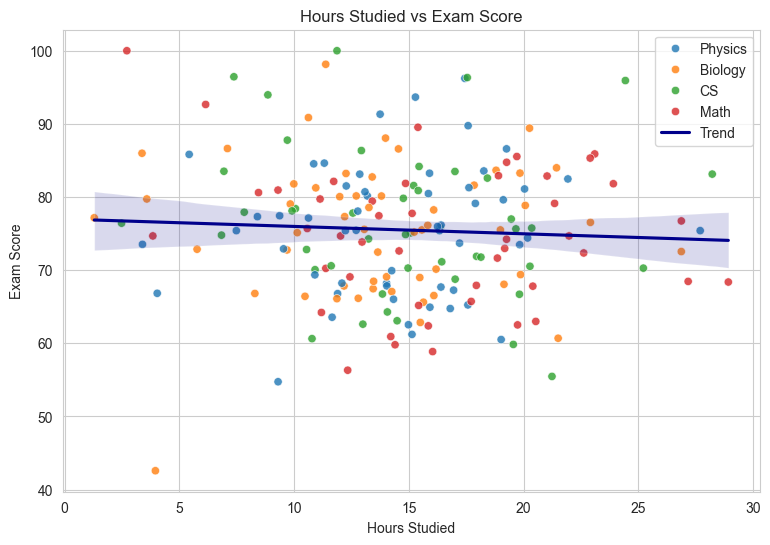

C:\Users\lenovo\AppData\Local\Temp\ipykernel_33308\209805951.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\lenovo\AppData\Local\Temp\ipykernel_33308\209805951.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="year", ax=axes[0, 1], palette="pastel")
C:\Users\lenovo\AppData\Local\Temp\ipykernel_33308\209805951.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


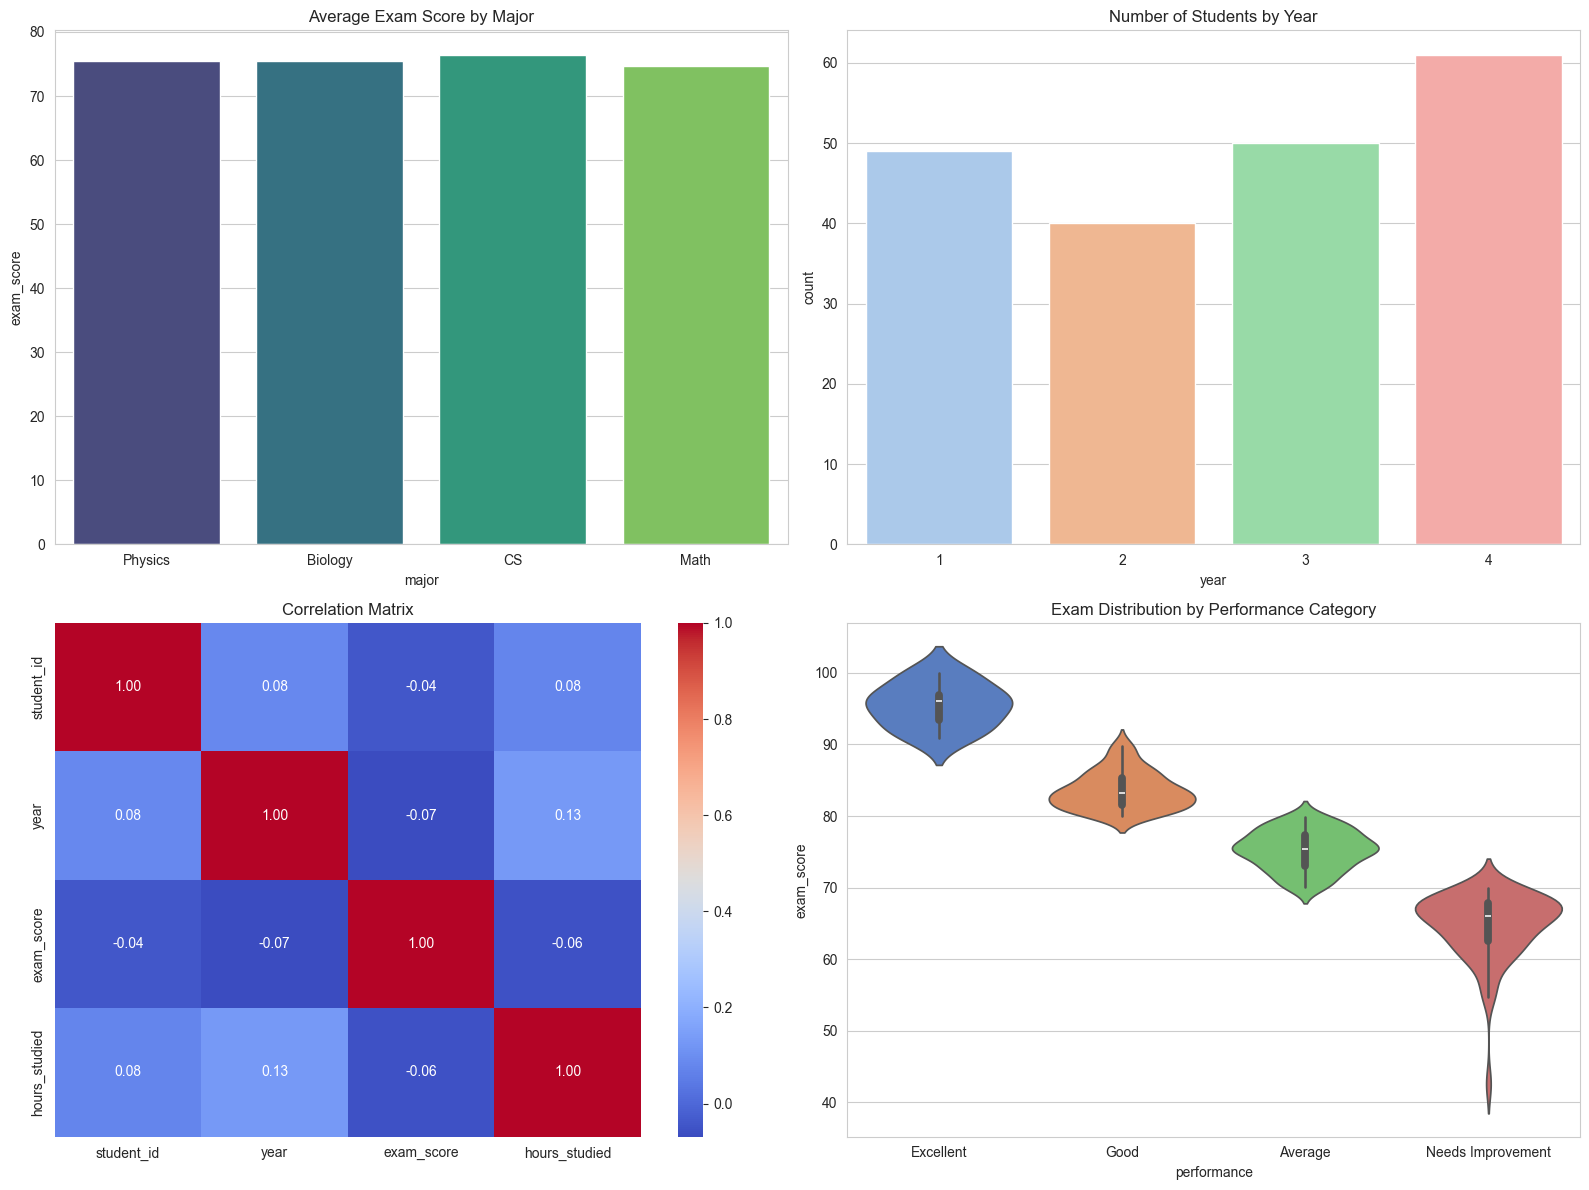

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Task 1: Distribution Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x="exam_score", kde=True, ax=axes[0], color="red")
axes[0].set_title("Distribution of Exam Scores")
sns.boxplot(data=df, x="major", y="exam_score", ax=axes[1], palette="Set2")
axes[1].set_title("Exam Scores by Major")
plt.tight_layout()
plt.show()

# Task 2: Relationship Visualization
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="hours_studied", y="exam_score", hue="major", alpha=0.8)
sns.regplot(
    data=df,
    x="hours_studied",
    y="exam_score",
    scatter=False,
    color="darkblue",
    label="Trend",
)
plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend()
plt.show()

# Task 3: Advanced Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.barplot(
    data=df, x="major", y="exam_score", ax=axes[0, 0], errorbar=None, palette="viridis"
)
axes[0, 0].set_title("Average Exam Score by Major")

sns.countplot(data=df, x="year", ax=axes[0, 1], palette="pastel")
axes[0, 1].set_title("Number of Students by Year")

numerical_cols = df.select_dtypes(include=["int64", "float64"]).corr()
sns.heatmap(numerical_cols, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1, 0])
axes[1, 0].set_title("Correlation Matrix")

sns.violinplot(
    data=df,
    x="performance",
    y="exam_score",
    ax=axes[1, 1],
    palette="muted",
    order=["Excellent", "Good", "Average", "Needs Improvement"],
)
axes[1, 1].set_title("Exam Distribution by Performance Category")

plt.tight_layout()
plt.show()



Exercise 7 (Integration Challenge)

--- Age Group Summary ---
  age_group  customer_count    avg_income     avg_clv      total_clv
0     18-25              81  50634.018330  718.371170   58188.064760
1     26-35              73  48747.148046  747.738562   54584.915035
2     36-50             160  48516.895668  732.796612  117247.457917
3     51-70             186  50713.163384  762.693498  141860.990683


C:\Users\lenovo\AppData\Local\Temp\ipykernel_33308\1060166089.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


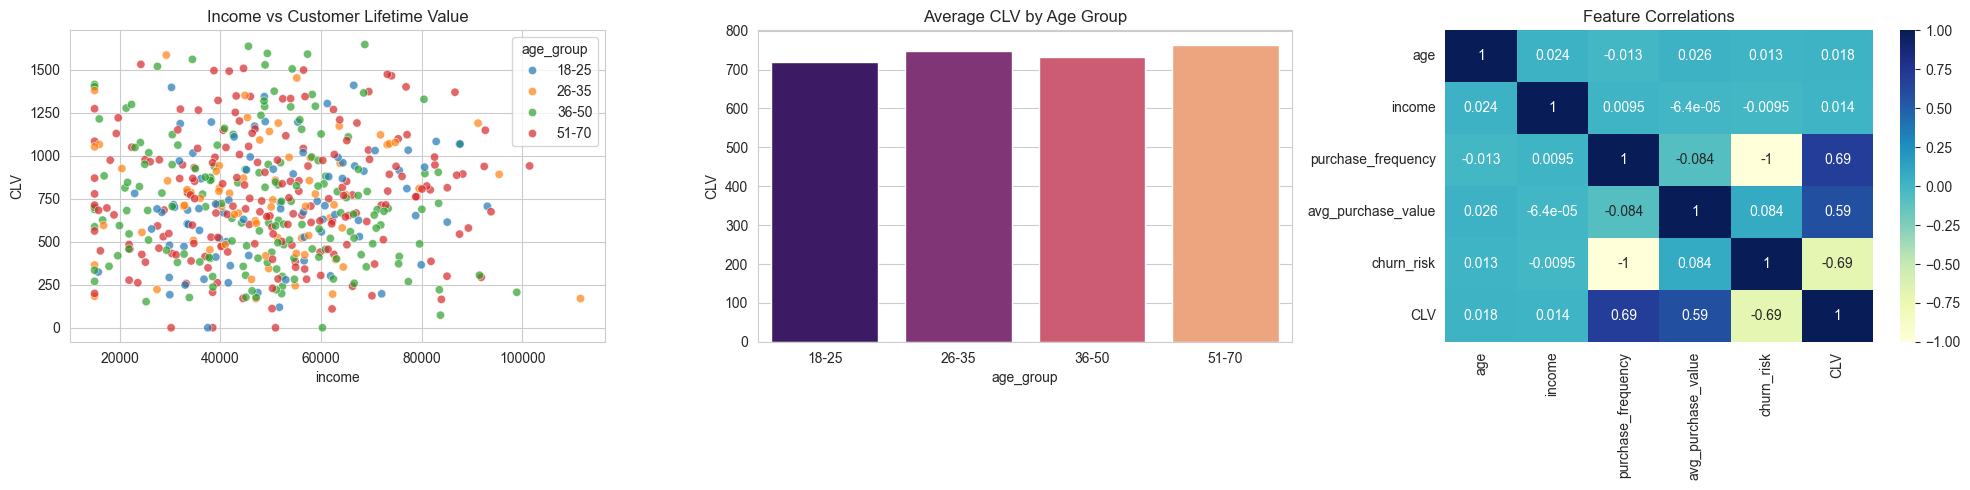

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n_customers = 500

customers = pd.DataFrame(
    {
        "age": np.random.randint(18, 70, n_customers),
        "income": np.random.normal(50000, 20000, n_customers).clip(15000, 150000),
        "purchase_frequency": np.random.poisson(5, n_customers),
        "avg_purchase_value": np.random.normal(100, 30, n_customers).clip(10, 500),
    }
)

# Calculate Churn Risk & CLV
max_freq = customers["purchase_frequency"].max()
customers["churn_risk"] = 1 - (customers["purchase_frequency"] / max_freq)
customers["CLV"] = (
    customers["purchase_frequency"]
    * customers["avg_purchase_value"]
    * (1 + customers["churn_risk"])
)

# Define Age Groups
bins = [17, 25, 35, 50, 70]
labels = ["18-25", "26-35", "36-50", "51-70"]
customers["age_group"] = pd.cut(customers["age"], bins=bins, labels=labels)

# Metrics Aggregation
age_group_analysis = (
    customers.groupby("age_group")
    .agg(customer_count=("CLV", "count"),
        avg_income=("income", "mean"),
        avg_clv=("CLV", "mean"),
        total_clv=("CLV", "sum"),).reset_index()
)

print("--- Age Group Summary ---")
print(age_group_analysis)

# Top 10%
top_10_percent_cutoff = customers["CLV"].quantile(0.90)
top_customers = customers[customers["CLV"] >= top_10_percent_cutoff]

# Multi-Plot Generation
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.scatterplot(
    data=customers, x="income", y="CLV", hue="age_group", alpha=0.7, ax=axes[0]
)
axes[0].set_title("Income vs Customer Lifetime Value")

sns.barplot(
    data=customers, x="age_group", y="CLV", ax=axes[1], palette="magma", errorbar=None
)
axes[1].set_title("Average CLV by Age Group")

sns.heatmap(
    customers.select_dtypes(include=[np.number]).corr(),
    annot=True,
    cmap="YlGnBu",
    ax=axes[2],
)
axes[2].set_title("Feature Correlations")
plt.tight_layout()
plt.show()


### Executive Summary & Analysis Findings
our data shows the fact that the total lifetime value  of customer depends mostly on two things: the way the buy  and the way they spend every time. we also noticed that there is a difference acrross age groups, with older customers between 36 to 70 years old briging in the most money because they shop with us in consistent way. To get the best result and boostour totalprofits, we should focus our marketing efforts on keeping the specific groups customer  who are at risk of leaving. By creating simple rewards or reminders that encourage these groups to build a regular habit of shoping, we can keep them engaged and steadly grow the revenue of our company.

